In [1]:
import pickle

# Load the saved model
with open("regression_trainer_model.pkl", "rb") as f:
    elastic_trainer = pickle.load(f)

# Print all attributes of the loaded object
attributes = {attr: getattr(elastic_trainer, attr) for attr in dir(elastic_trainer) if not attr.startswith("__")}
for key, value in attributes.items():
    print(f"{key}: {type(value)}")  # Print attribute names and types


apply_filter: <class 'bool'>
filter_size: <class 'int'>
filter_threshold: <class 'float'>
get_model_summary: <class 'method'>
include_prices: <class 'bool'>
last_test_timestamp: <class 'str'>
last_train_timestamp: <class 'str'>
make_predictions: <class 'method'>
model: <class 'sklearn.linear_model._coordinate_descent.ElasticNet'>
mse_filtered: <class 'NoneType'>
mse_unfiltered: <class 'NoneType'>
predictions: <class 'numpy.ndarray'>
predictions_filtered: <class 'numpy.ndarray'>
prepare_data: <class 'method'>
r2_filtered: <class 'NoneType'>
r2_unfiltered: <class 'NoneType'>
regression_figure: <class 'NoneType'>
train_model: <class 'method'>
x_test: <class 'pandas.core.frame.DataFrame'>
x_test_filtered: <class 'NoneType'>
x_test_with_meta: <class 'pandas.core.frame.DataFrame'>
x_train: <class 'pandas.core.frame.DataFrame'>
y_test: <class 'pandas.core.series.Series'>
y_test_filtered: <class 'pandas.core.series.Series'>
y_train: <class 'pandas.core.series.Series'>


In [2]:
# Print the column names and preview the data to confirm structure
print("🔹 x_test_with_meta Columns:", elastic_trainer.x_test_with_meta.columns.tolist())
print("🔹 y_test (Actual Values) Sample:", elastic_trainer.y_test.tail(5))
print("🔹 Predictions Sample:", elastic_trainer.predictions[-5:])


🔹 x_test_with_meta Columns: ['Volume', 'FastAvg', 'SlowAvg', 'FastEMA', 'MedEMA', 'SlowEMA', 'ADX', 'DMI_plus', 'DMI_minus', 'AroonUp', 'AroonDn', 'AroonOsc', 'Typical_Price', 'Cum_PxV', 'Cum_Volume', 'VWAP', 'Fibo_High', 'Fibo_Low', 'UpperBand.2', 'LowerBand.2', 'CCI', 'CCI_Avg', 'Tenkan', 'Kijun', 'Chikou', 'SenkouSpan_A', 'SenkouSpan_B', 'Prev_Close', 'TR1', 'TR2', 'TR3', 'True_Range', 'ATR', 'ATR+ High', 'ATR+ Low', 'ATR+ Close', 'ATR+ Open', 'EMA_5', 'Close_vs_EMA_5', 'Open_vs_EMA_5', 'EMA_10', 'Close_vs_EMA_10', 'Open_vs_EMA_10', 'EMA_15', 'Close_vs_EMA_15', 'Open_vs_EMA_15', 'EMA_20', 'Close_vs_EMA_20', 'Open_vs_EMA_20', 'EMA_25', 'Close_vs_EMA_25', 'Open_vs_EMA_25', 'EMA_30', 'Close_vs_EMA_30', 'Open_vs_EMA_30', 'EMA_35', 'Close_vs_EMA_35', 'Open_vs_EMA_35', 'EMA_40', 'Close_vs_EMA_40', 'Open_vs_EMA_40', 'EMA_45', 'Close_vs_EMA_45', 'Open_vs_EMA_45', 'EMA_50', 'Close_vs_EMA_50', 'Open_vs_EMA_50', 'EMA_5_High', 'High_vs_EMA_5_High', 'EMA_10_High', 'High_vs_EMA_10_High', 'EMA_15_

In [4]:
# Merge x_test_with_meta (Date, Time, OHLC) with y_test (Actual Next_High) and Predictions
df_test_results = elastic_trainer.x_test_with_meta[["Date", "Time", "Open", "High", "Low", "Close"]].copy()
df_test_results["Next_High"] = elastic_trainer.y_test.values  # Actual next high
df_test_results["Predicted_High"] = elastic_trainer.predictions  # Predicted next high

# Display the last 10 rows to inspect
import pandas as pd
df_test_results


,Date,Time,Open,High,Low,Close,Next_High,Predicted_High
7999,01/13/2025,08:35,5845.50,5847.50,5845.00,5845.00,5846.00,5846.216504
8000,01/13/2025,08:40,5845.00,5846.00,5842.25,5842.75,5845.75,5844.482690
8001,01/13/2025,08:45,5843.00,5845.75,5842.50,5844.00,5845.75,5845.082361
8002,01/13/2025,08:50,5844.25,5845.75,5843.75,5844.00,5845.50,5845.258391
8003,01/13/2025,08:55,5844.00,5845.50,5843.75,5845.00,5845.00,5845.964307
...,...,...,...,...,...,...,...,...
9994,01/22/2025,18:00,6124.00,6125.00,6121.75,6122.50,6123.00,6123.300281
9995,01/22/2025,18:05,6122.25,6123.00,6120.50,6121.75,6125.00,6122.885754
9996,01/22/2025,18:10,6122.00,6125.00,6122.00,6124.00,6124.00,6124.687297
9997,01/22/2025,18:15,6123.75,6124.00,6119.50,6121.00,6124.75,6122.578329


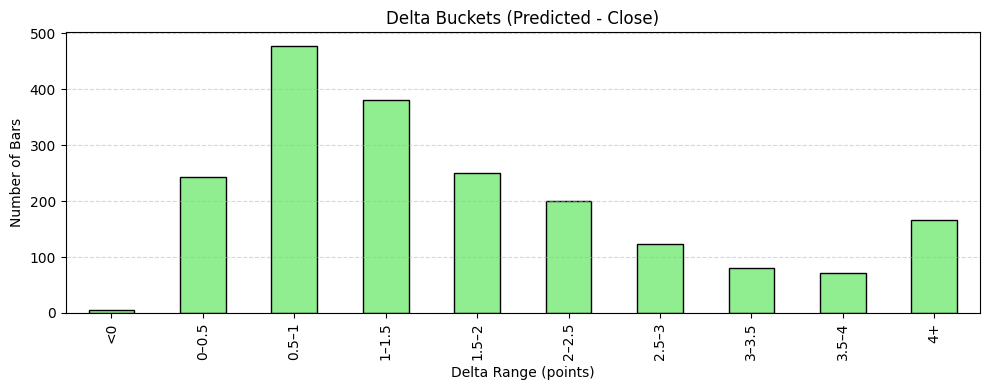

,Date,Time,Close,Predicted_High,Delta,Delta_Bucket
9994,01/22/2025,18:00,6122.50,6123.300281,0.800281,0.5–1
9995,01/22/2025,18:05,6121.75,6122.885754,1.135754,1–1.5
9996,01/22/2025,18:10,6124.00,6124.687297,0.687297,0.5–1
9997,01/22/2025,18:15,6121.00,6122.578329,1.578329,1.5–2
9998,01/22/2025,18:20,6124.25,6125.071266,0.821266,0.5–1


In [7]:
import matplotlib.pyplot as plt

# Calculate delta
df_test_results["Delta"] = df_test_results["Predicted_High"] - df_test_results["Close"]

bins = [-float("inf"), 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, float("inf")]
labels = ["<0", "0–0.5", "0.5–1", "1–1.5", "1.5–2", "2–2.5", "2.5–3", "3–3.5", "3.5–4", "4+"]

# Categorize
df_test_results["Delta_Bucket"] = pd.cut(df_test_results["Delta"], bins=bins, labels=labels, right=False)

# Count and sort
bucket_counts = df_test_results["Delta_Bucket"].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 4))
bucket_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Delta Buckets (Predicted - Close)")
plt.xlabel("Delta Range (points)")
plt.ylabel("Number of Bars")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: preview
df_test_results[["Date", "Time", "Close", "Predicted_High", "Delta", "Delta_Bucket"]].tail()


In [8]:
# Step 1: Create a copy of the test set
df_test_results = elastic_trainer.x_test_with_meta.copy()
df_test_results["Predicted"] = elastic_trainer.predictions
df_test_results["Actual"] = elastic_trainer.y_test.values

# Step 2: Compute difference between prediction and close
df_test_results["Predicted_Diff"] = df_test_results["Predicted"] - df_test_results["Close"]

# Step 3: Filter only predictions >= 1.0
high_conf_preds = df_test_results[df_test_results["Predicted_Diff"] >= 1.0]

# Step 4: Determine how many of those actually reached >= Close + 1.0
high_conf_preds["Is_Good"] = high_conf_preds["Actual"] >= (high_conf_preds["Close"] + 1.0)

# Step 5: Count results
total_candidates = len(high_conf_preds)
num_good = high_conf_preds["Is_Good"].sum()
percent_good = 100 * num_good / total_candidates if total_candidates > 0 else 0

print(f"📈 Total predictions >= 1.0 points: {total_candidates}")
print(f"✅ Number of 'good' bars (Actual >= Close + 1.0): {num_good}")
print(f"🎯 Percentage good: {percent_good:.2f}%")


📈 Total predictions >= 1.0 points: 1274
✅ Number of 'good' bars (Actual >= Close + 1.0): 933
🎯 Percentage good: 73.23%


C:\Users\itzha\AppData\Local\Temp\ipykernel_22228\2043417231.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_conf_preds["Is_Good"] = high_conf_preds["Actual"] >= (high_conf_preds["Close"] + 1.0)


C:\Users\itzha\AppData\Local\Temp\ipykernel_22228\2306050118.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


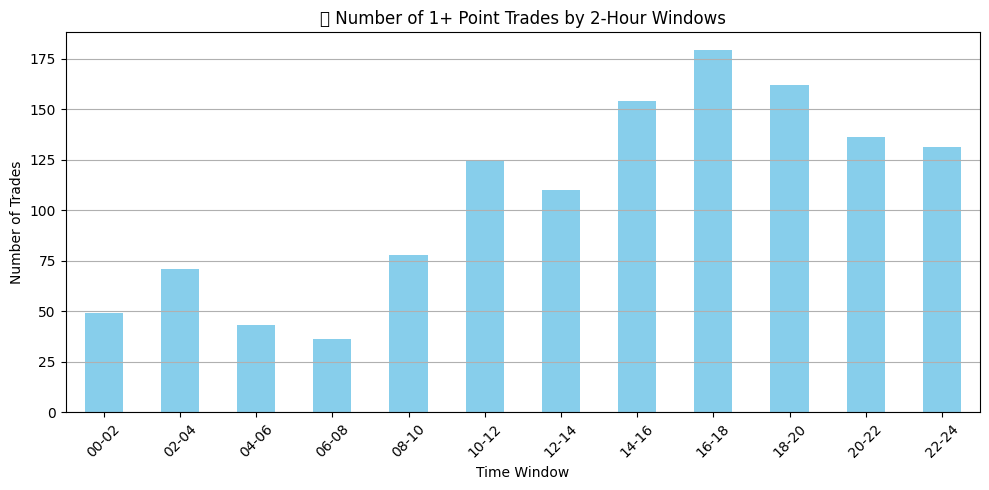

In [11]:
# Step 1: Create prediction - close column
df_test_results['prediction_minus_close'] = df_test_results['Predicted'] - df_test_results['Close']

# Step 2: Filter for 1+ point trades
df_above_1 = df_test_results[df_test_results['prediction_minus_close'] >= 1.0].copy()

# Step 3: Convert "Time" to hour
df_above_1['Hour'] = pd.to_datetime(df_above_1['Time'], format='%H:%M').dt.hour

# Step 4: Group into 2-hour bins
bins = list(range(0, 25, 2))  # 0, 2, 4, ..., 22, 24
labels = [f"{h:02d}-{h+2:02d}" for h in bins[:-1]]
df_above_1['HourRange'] = pd.cut(df_above_1['Hour'], bins=bins, labels=labels, right=False)

# Step 5: Count occurrences
time_distribution = df_above_1['HourRange'].value_counts().sort_index()

# Step 6: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
time_distribution.plot(kind='bar', color='skyblue')
plt.title("📊 Number of 1+ Point Trades by 2-Hour Windows")
plt.xlabel("Time Window")
plt.ylabel("Number of Trades")
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


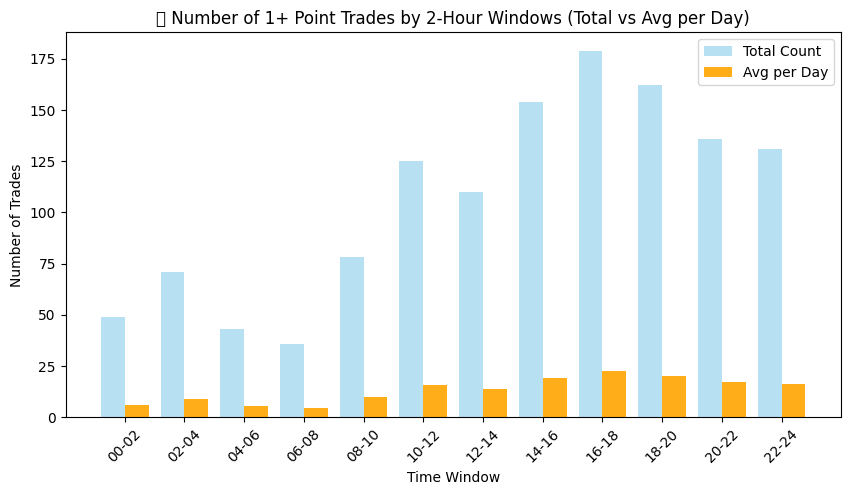

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Count trades per 2-hour window
df_above_1['Time Window'] = pd.cut(
    df_above_1['Hour'],
    bins=list(range(0, 26, 2)),  # 0-2, 2-4, ..., 22-24
    labels=[f"{str(i).zfill(2)}-{str(i+2).zfill(2)}" for i in range(0, 24, 2)],
    right=False
)

# Step 2: Count occurrences per time window
trade_counts = df_above_1['Time Window'].value_counts().sort_index()

# Step 3: Compute number of unique days
num_days = df_above_1['Date'].nunique()

# Step 4: Compute average trades per day
trade_avg_per_day = trade_counts / num_days

# Step 5: Plot both bars
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.4  # Adjust spacing between bars

# Plot total count
ax.bar(np.arange(len(trade_counts)) - bar_width/2, trade_counts, width=bar_width, alpha=0.6, label="Total Count", color="skyblue")

# Plot average per day
ax.bar(np.arange(len(trade_avg_per_day)) + bar_width/2, trade_avg_per_day, width=bar_width, alpha=0.9, label="Avg per Day", color="orange")

# Formatting
ax.set_xticks(np.arange(len(trade_counts)))
ax.set_xticklabels(trade_counts.index, rotation=45)
ax.set_ylabel("Number of Trades")
ax.set_xlabel("Time Window")
ax.set_title("📊 Number of 1+ Point Trades by 2-Hour Windows (Total vs Avg per Day)")
ax.legend()

plt.show()
